# NB13 — Physics-Based Solar Model Calibration

**Goal**: Replace the naive `solar_w × GHI` term with a physics-based solar model  
inspired by [thuemah/heating_analytics](https://github.com/thuemah/heating_analytics).

**Why**: Our nighttime HLC script showed:
- Nighttime HLC = 0.005 (building barely cools through envelope)
- All-data free HLC = 0.449 (90× higher → compensating for bad solar model)
- Dual-HLC RMSE = 0.329 vs single-HLC = 0.447 (0.12°C gap)
- Solar GHI is critical: RMSE 1.09 (no solar) → 0.45 (with solar)

The dual-HLC "improvement" is the optimizer using HLC_on (correlated with daytime/PV)
as a proxy for missing solar physics. A proper solar model should close that gap.

**Physics components** (from heating_analytics DESIGN.md):
1. Sun position (elevation, azimuth) via `astral`
2. Air mass transmittance: `intensity = 0.7^(1/sin(elevation))`
3. Cloud factor (Kasten 1980): `1 - 0.75 × (cloud%/100)^3.4`
4. Erbs (1982) decomposition: GHI → DNI + DHI
5. 3D directional vector: South / East / West components
6. Solar thermal battery (EMA decay)
7. Saturation logic

---
## Section A — Data Loading & Open Meteo Fetch

In [1]:
import sys, warnings, calendar, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize, stats
from pathlib import Path
from datetime import datetime, timedelta
import pytz
import requests, urllib3

from astral import Observer
from astral.sun import elevation as sun_elevation, azimuth as sun_azimuth

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "Logs_and_models" / "cooling_training_data.csv.gz"
LAT, LON = 48.928, 10.069
TZ = pytz.timezone("Europe/Berlin")
OBSERVER = Observer(latitude=LAT, longitude=LON)

# --- Load training data ---
df = pd.read_csv(DATA_PATH)
df["hour"] = (np.degrees(np.arctan2(df["hour_sin"], df["hour_cos"])) / 15) % 24
df["driving_force"] = df["indoor_temp"] - df["AT"]
mask_clean = (df["AT"] > -10) & (df["AT"] < 45) & (df["VLT"] > 10) & (df["VLT"] < 45)
df = df[mask_clean].copy().reset_index(drop=True)

# Reconstruct approximate timestamps from doy_sin/cos and hour
doy_angle = np.arctan2(df["doy_sin"], df["doy_cos"])
doy_vals = (doy_angle * 365.25 / (2 * np.pi)) % 365.25
df["doy_approx"] = doy_vals.round().astype(int).clip(1, 365)
df["hour_approx"] = df["hour"].round().astype(int).clip(0, 23)

print(f"Training data: {len(df)} rows, columns: {len(df.columns)}")
print(f"DOY range: {df['doy_approx'].min()} – {df['doy_approx'].max()}")
print(f"Hour range: {df['hour_approx'].min()} – {df['hour_approx'].max()}")

Training data: 47933 rows, columns: 80
DOY range: 42 – 344
Hour range: 0 – 23


In [2]:
# --- Fetch Open Meteo: GHI, cloud_cover, DNI, DHI ---
chunks = []
print("Fetching Open Meteo solar + cloud data (monthly chunks)...")
y, m = 2025, 5
while (y, m) <= (2026, 5):
    last_day = calendar.monthrange(y, m)[1]
    s_str = f"{y}-{m:02d}-01"
    e_str = f"{y}-{m:02d}-{last_day:02d}"
    try:
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={LAT}&longitude={LON}&start_date={s_str}&end_date={e_str}"
            f"&hourly=shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation"
            f"&timezone=Europe%2FBerlin"
        )
        resp = requests.get(url, timeout=60, verify=False)
        resp.raise_for_status()
        data = resp.json()
        h = data["hourly"]
        chunk_df = pd.DataFrame({
            "timestamp": pd.to_datetime(h["time"]),
            "ghi_wm2": h["shortwave_radiation"],
            "cloud_cover": h["cloud_cover"],
            "dni_wm2": h["direct_normal_irradiance"],
            "dhi_wm2": h["diffuse_radiation"],
        })
        chunks.append(chunk_df)
        print(f"  {s_str}: {len(chunk_df)} rows OK")
    except Exception as e:
        print(f"  {s_str}: FAILED ({str(e)[:80]})")
    m += 1
    if m > 12:
        m, y = 1, y + 1

solar_df = pd.concat(chunks, ignore_index=True).set_index("timestamp").sort_index()
solar_df = solar_df[~solar_df.index.duplicated(keep="first")]
print(f"\nOpen Meteo data: {len(solar_df)} rows, {solar_df.index[0]} → {solar_df.index[-1]}")
print(f"Cloud cover range: {solar_df['cloud_cover'].min()} – {solar_df['cloud_cover'].max()}")
print(f"GHI range: {solar_df['ghi_wm2'].min()} – {solar_df['ghi_wm2'].max()} W/m²")
print(f"DNI range: {solar_df['dni_wm2'].min()} – {solar_df['dni_wm2'].max()} W/m²")

Fetching Open Meteo solar + cloud data (monthly chunks)...
  2025-05-01: 744 rows OK
  2025-06-01: 720 rows OK
  2025-07-01: 744 rows OK
  2025-08-01: 744 rows OK
  2025-09-01: 720 rows OK
  2025-10-01: 744 rows OK
  2025-11-01: 720 rows OK
  2025-12-01: 744 rows OK
  2026-01-01: 744 rows OK
  2026-02-01: 672 rows OK
  2026-03-01: 744 rows OK
  2026-04-01: 720 rows OK
  2026-05-01: 744 rows OK

Open Meteo data: 9504 rows, 2025-05-01 00:00:00 → 2026-05-31 23:00:00
Cloud cover range: 0 – 100
GHI range: 0.0 – 918.0 W/m²
DNI range: 0.0 – 928.6 W/m²


Computing sun positions via astral...


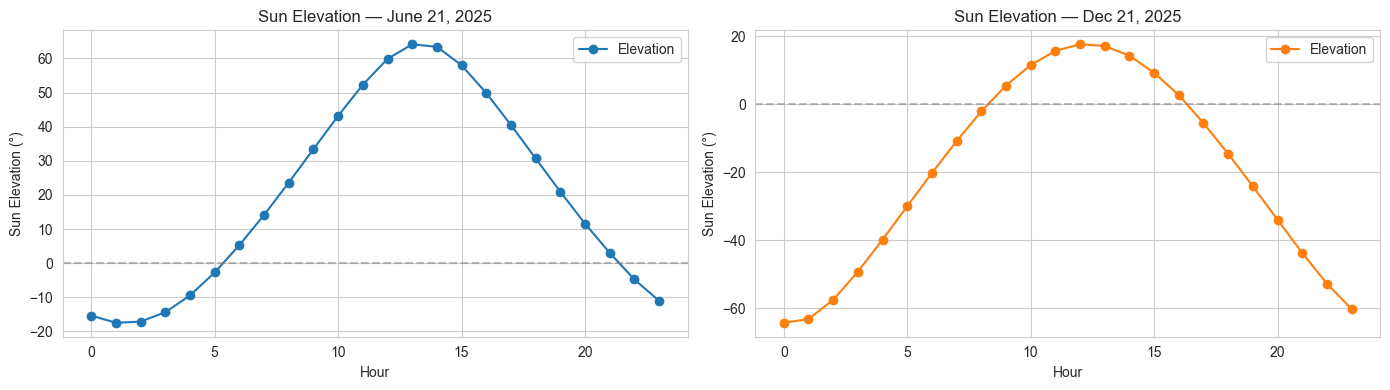

Sun elevation range: -64.3° – 64.2°


In [3]:
# --- Compute sun position for every Open Meteo timestamp ---
print("Computing sun positions via astral...")
elev_arr = np.zeros(len(solar_df))
azim_arr = np.zeros(len(solar_df))

for i, ts in enumerate(solar_df.index):
    dt = ts.to_pydatetime()
    if dt.tzinfo is None:
        dt = TZ.localize(dt)
    try:
        elev_arr[i] = sun_elevation(OBSERVER, dt)
        azim_arr[i] = sun_azimuth(OBSERVER, dt)
    except Exception:
        elev_arr[i] = 0.0
        azim_arr[i] = 180.0

solar_df["sun_elevation"] = elev_arr
solar_df["sun_azimuth"] = azim_arr
solar_df["sun_elevation_rad"] = np.radians(np.clip(elev_arr, 0, 90))

# Quick sanity plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Summer solstice day
summer = solar_df.loc["2025-06-21"]
ax1.plot(summer.index.hour, summer["sun_elevation"], "o-", label="Elevation")
ax1.axhline(0, color="gray", ls="--", alpha=0.5)
ax1.set_xlabel("Hour"); ax1.set_ylabel("Sun Elevation (°)")
ax1.set_title("Sun Elevation — June 21, 2025"); ax1.legend()

# Winter solstice day
winter = solar_df.loc["2025-12-21"]
ax2.plot(winter.index.hour, winter["sun_elevation"], "o-", color="tab:orange", label="Elevation")
ax2.axhline(0, color="gray", ls="--", alpha=0.5)
ax2.set_xlabel("Hour"); ax2.set_ylabel("Sun Elevation (°)")
ax2.set_title("Sun Elevation — Dec 21, 2025"); ax2.legend()

plt.tight_layout(); plt.show()
print(f"Sun elevation range: {solar_df['sun_elevation'].min():.1f}° – {solar_df['sun_elevation'].max():.1f}°")

## Section B — Physics Solar Model

Three approaches:
1. **Kasten cloud model**: `clear_sky × (1 - 0.75 × (cloud/100)^3.4)`, clear sky from air mass transmittance
2. **Erbs decomposition**: Measured GHI → split into DNI + DHI via clearness index
3. **Open Meteo direct**: Use pre-computed DNI + DHI from Open Meteo

All approaches produce directional solar heat gain (South, East, West) that enters the building.

In [7]:
def compute_physics_solar(sun_elev_rad, sun_azim_deg, ghi, cloud_pct, dni_meteo, dhi_meteo):
    """
    Compute physics-based solar heat gain for each timestep.

    Returns dict with multiple solar model outputs for comparison.
    All arrays same length as inputs.
    """
    n = len(ghi)
    sin_elev = np.sin(sun_elev_rad)
    cos_elev = np.cos(sun_elev_rad)
    az_rad = np.radians(sun_azim_deg)

    # --- Masks ---
    MIN_ELEV_DEG = 5.0
    MIN_SIN = np.sin(np.radians(MIN_ELEV_DEG))
    ERBS_MIN_ELEV_DEG = 10.0  # higher threshold for Erbs (1/sin amplification)
    ERBS_MIN_SIN = np.sin(np.radians(ERBS_MIN_ELEV_DEG))
    sun_up = sin_elev > MIN_SIN
    erbs_valid = sin_elev > ERBS_MIN_SIN

    # =====================================================
    # MODEL 1: Kasten cloud model (cloud_cover based)
    # =====================================================
    air_mass = np.where(sun_up, 1.0 / np.clip(sin_elev, MIN_SIN, 1.0), 0.0)
    clear_sky_dni = np.where(sun_up, 1361.0 * (0.7 ** (air_mass ** 0.678)), 0.0)
    cloud_frac = np.clip(cloud_pct / 100.0, 0, 1)
    kasten_factor = 1.0 - 0.75 * (cloud_frac ** 3.4)
    kasten_dni = clear_sky_dni * kasten_factor
    kasten_dhi = np.where(sun_up, clear_sky_dni * sin_elev * 0.1 * (1 + 2.0 * cloud_frac), 0.0)

    # =====================================================
    # MODEL 2: Erbs decomposition (GHI based)
    # =====================================================
    I0_h = np.where(erbs_valid, 1361.0 * sin_elev, 0.001)
    kT = np.where(erbs_valid, np.clip(ghi / np.clip(I0_h, 1.0, None), 0, 1), 0.0)
    kd = np.where(
        kT <= 0.22,
        1.0 - 0.09 * kT,
        np.where(
            kT <= 0.80,
            0.9511 - 0.1604*kT + 4.388*kT**2 - 16.638*kT**3 + 12.336*kT**4,
            0.165
        )
    )
    erbs_dhi = np.where(erbs_valid, kd * ghi, 0.0)
    erbs_dni = np.where(erbs_valid,
                         (ghi - erbs_dhi) / np.clip(sin_elev, ERBS_MIN_SIN, 1.0), 0.0)
    erbs_dni = np.clip(erbs_dni, 0, 900)  # clear-sky DNI ≈ 800-900 at ground level

    # =====================================================
    # MODEL 3: Open Meteo direct DNI/DHI
    # =====================================================
    meteo_dni = np.clip(dni_meteo, 0, 1000)
    meteo_dhi = np.clip(dhi_meteo, 0, 500)

    # =====================================================
    # Directional solar vectors (common for all models)
    # =====================================================
    # Azimuth convention (astral): N=0°, E=90°, S=180°, W=270°
    def directional_gains(dni, dhi, mask):
        """Compute S/E/W solar gains from DNI + DHI."""
        beam_v = np.where(mask, dni * cos_elev, 0.0)
        south = np.where(mask, beam_v * np.clip(-np.cos(az_rad), 0, 1), 0.0)
        east = np.where(mask, beam_v * np.clip(np.sin(az_rad), 0, 1), 0.0)
        west = np.where(mask, beam_v * np.clip(-np.sin(az_rad), 0, 1), 0.0)
        # Cap per-wall beam to physical max (clear-sky DNI on vertical ≈ 800)
        south = np.clip(south, 0, 800)
        east = np.clip(east, 0, 800)
        west = np.clip(west, 0, 800)
        diff_wall = np.where(mask, dhi * 0.5, 0.0)
        total = (south + east + west) + 3 * diff_wall
        return south, east, west, total

    kasten_s, kasten_e, kasten_w, kasten_total = directional_gains(kasten_dni, kasten_dhi, sun_up)
    erbs_s, erbs_e, erbs_w, erbs_total = directional_gains(erbs_dni, erbs_dhi, erbs_valid)
    meteo_s, meteo_e, meteo_w, meteo_total = directional_gains(meteo_dni, meteo_dhi, sun_up)

    return {
        "air_mass": air_mass, "clear_sky_dni": clear_sky_dni,
        "kasten_factor": kasten_factor, "clearness_kT": kT, "erbs_kd": kd,
        "kasten_total": kasten_total, "erbs_total": erbs_total, "meteo_total": meteo_total,
        "kasten_south": kasten_s, "kasten_east": kasten_e, "kasten_west": kasten_w,
        "erbs_south": erbs_s, "erbs_east": erbs_e, "erbs_west": erbs_w,
        "meteo_south": meteo_s, "meteo_east": meteo_e, "meteo_west": meteo_w,
        "naive_ghi": ghi,
    }

# Compute physics solar for all Open Meteo timestamps
results = compute_physics_solar(
    solar_df["sun_elevation_rad"].values,
    solar_df["sun_azimuth"].values,
    solar_df["ghi_wm2"].values,
    solar_df["cloud_cover"].values,
    solar_df["dni_wm2"].values,
    solar_df["dhi_wm2"].values,
)

for key, val in results.items():
    solar_df[key] = val

print("Physics solar models computed.")
print(f"\nDaily peak comparison (summer 2025-06-21):")
summer = solar_df.loc["2025-06-21"]
for model in ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]:
    print(f"  {model:15s}: peak = {summer[model].max():.0f} W/m²")
print(f"\nWinter day 2025-12-21:")
winter = solar_df.loc["2025-12-21"]
for model in ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]:
    print(f"  {model:15s}: peak = {winter[model].max():.0f} W/m²")
print(f"\nSummer/Winter ratio (should be >1 for directional):")
for model in ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]:
    s, w = summer[model].max(), max(winter[model].max(), 1)
    print(f"  {model:15s}: {s/w:.1f}x")

Physics solar models computed.

Daily peak comparison (summer 2025-06-21):
  naive_ghi      : peak = 899 W/m²
  kasten_total   : peak = 861 W/m²
  erbs_total     : peak = 952 W/m²
  meteo_total    : peak = 900 W/m²

Winter day 2025-12-21:
  naive_ghi      : peak = 232 W/m²
  kasten_total   : peak = 611 W/m²
  erbs_total     : peak = 994 W/m²
  meteo_total    : peak = 825 W/m²

Summer/Winter ratio (should be >1 for directional):
  naive_ghi      : 3.9x
  kasten_total   : 1.4x
  erbs_total     : 1.0x
  meteo_total    : 1.1x


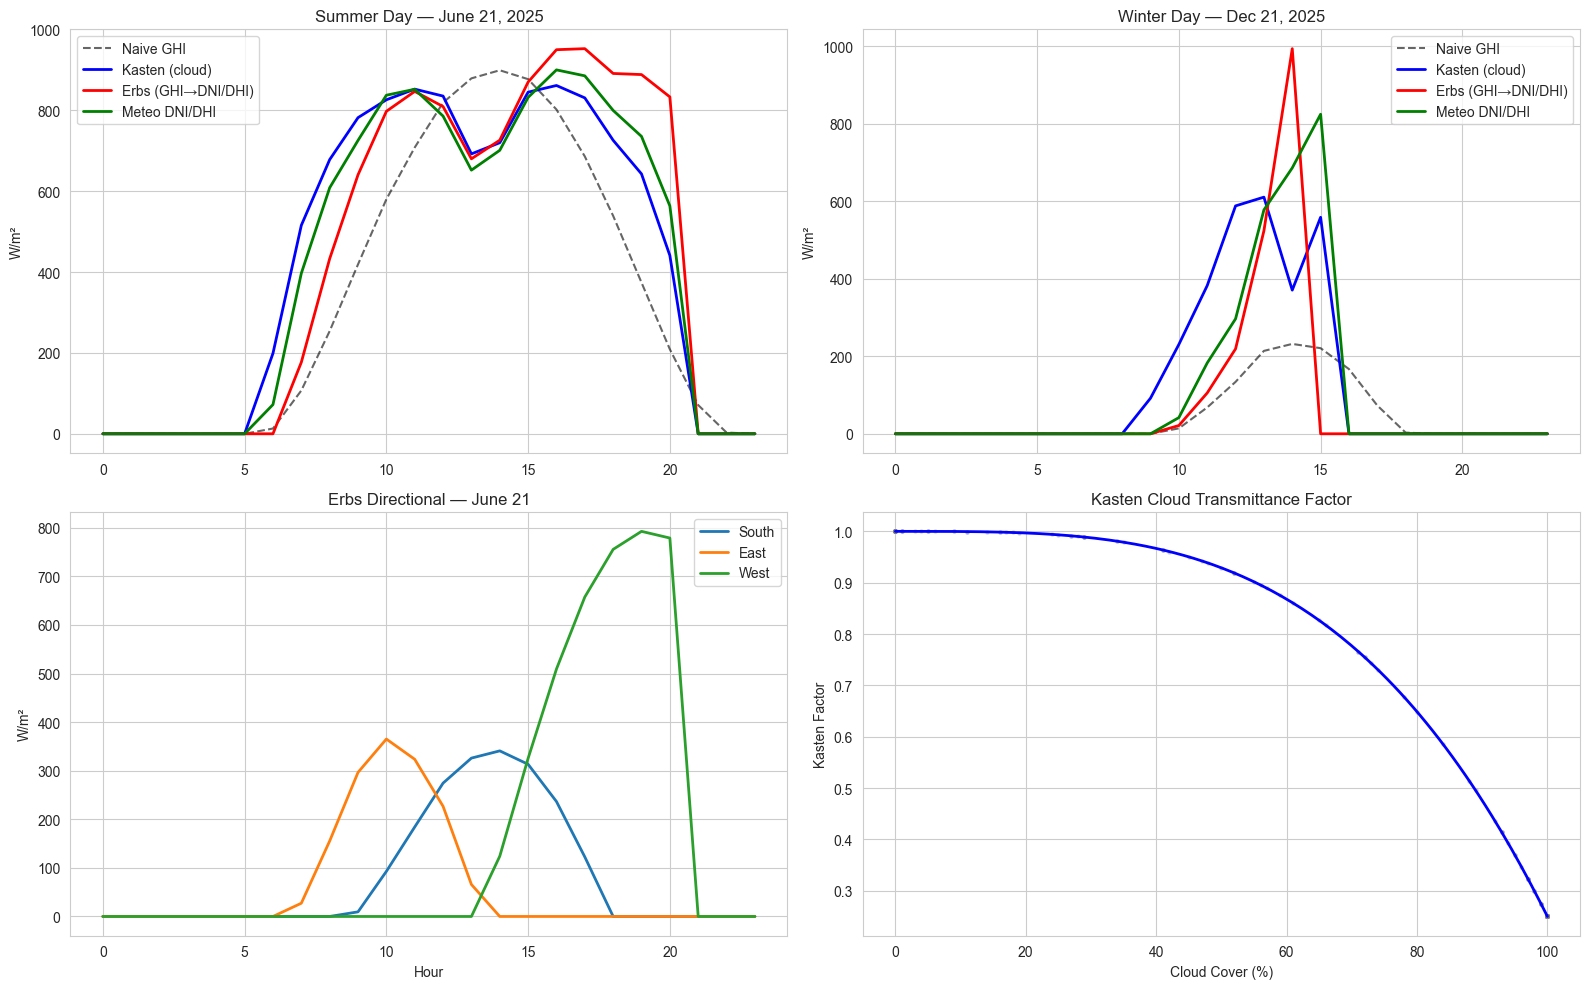

In [8]:
# --- Compare solar models visually ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Summer day comparison
summer = solar_df.loc["2025-06-21"]
ax = axes[0, 0]
ax.plot(summer.index.hour, summer["naive_ghi"], "k--", label="Naive GHI", alpha=0.6)
ax.plot(summer.index.hour, summer["kasten_total"], "b-", label="Kasten (cloud)", lw=2)
ax.plot(summer.index.hour, summer["erbs_total"], "r-", label="Erbs (GHI→DNI/DHI)", lw=2)
ax.plot(summer.index.hour, summer["meteo_total"], "g-", label="Meteo DNI/DHI", lw=2)
ax.set_title("Summer Day — June 21, 2025"); ax.set_ylabel("W/m²"); ax.legend()

# Winter day comparison
winter = solar_df.loc["2025-12-21"]
ax = axes[0, 1]
ax.plot(winter.index.hour, winter["naive_ghi"], "k--", label="Naive GHI", alpha=0.6)
ax.plot(winter.index.hour, winter["kasten_total"], "b-", label="Kasten (cloud)", lw=2)
ax.plot(winter.index.hour, winter["erbs_total"], "r-", label="Erbs (GHI→DNI/DHI)", lw=2)
ax.plot(winter.index.hour, winter["meteo_total"], "g-", label="Meteo DNI/DHI", lw=2)
ax.set_title("Winter Day — Dec 21, 2025"); ax.set_ylabel("W/m²"); ax.legend()

# Directional breakdown (summer)
ax = axes[1, 0]
ax.plot(summer.index.hour, summer["erbs_south"], label="South", lw=2)
ax.plot(summer.index.hour, summer["erbs_east"], label="East", lw=2)
ax.plot(summer.index.hour, summer["erbs_west"], label="West", lw=2)
ax.set_title("Erbs Directional — June 21"); ax.set_ylabel("W/m²"); ax.legend()
ax.set_xlabel("Hour")

# Kasten factor vs cloud cover
ax = axes[1, 1]
cc = np.linspace(0, 100, 200)
ax.plot(cc, 1 - 0.75 * (cc/100)**3.4, "b-", lw=2)
ax.scatter(solar_df["cloud_cover"].values[::50],
           solar_df["kasten_factor"].values[::50], alpha=0.3, s=5, c="gray")
ax.set_xlabel("Cloud Cover (%)"); ax.set_ylabel("Kasten Factor")
ax.set_title("Kasten Cloud Transmittance Factor")

plt.tight_layout(); plt.show()

## Section C — Solar Thermal Battery (EMA Smoothing)

Solar heat doesn't instantly warm the house — thermal mass (concrete slab, walls) absorbs
radiation and re-emits over hours. We model this as an Exponential Moving Average (EMA):

$$\text{state}_{t} = \text{state}_{t-1} \cdot \alpha + \text{solar}_{t} \cdot (1 - \alpha)$$

where $\alpha$ = decay factor (0.5 = fast response, 0.95 = heavy damping).

We sweep $\alpha$ from 0.50 to 0.95 to find the optimal thermal battery time constant.

In [9]:
def apply_ema_battery(solar_series, decay):
    """Apply EMA thermal battery to a solar time series."""
    out = np.zeros_like(solar_series)
    state = 0.0
    for i in range(len(solar_series)):
        state = state * decay + solar_series[i] * (1 - decay)
        out[i] = state
    return out

# Merge solar data into training data by (doy, hour) average
# (Same approach as nighttime script — training data has no real timestamps)
solar_avg = solar_df.copy()
solar_avg["doy"] = solar_avg.index.dayofyear
solar_avg["hour_of_day"] = solar_avg.index.hour

# For EMA, we need to apply it on the time-ordered Open Meteo series FIRST,
# then average by (doy, hour) — this preserves the temporal smoothing
DECAY_VALUES = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
SOLAR_MODELS = ["naive_ghi", "kasten_total", "erbs_total", "meteo_total"]

# Apply EMA for each model × decay combination on the full time series
for model in SOLAR_MODELS:
    raw = solar_df[model].fillna(0).values
    for decay in DECAY_VALUES:
        col = f"{model}_ema{int(decay*100)}"
        solar_df[col] = apply_ema_battery(raw, decay)

# Build (doy, hour) averages for all solar columns
solar_cols = [c for c in solar_df.columns if c not in
              ["ghi_wm2", "cloud_cover", "dni_wm2", "dhi_wm2",
               "sun_elevation", "sun_azimuth", "sun_elevation_rad",
               "air_mass", "clear_sky_dni", "kasten_factor", "clearness_kT", "erbs_kd"]]
agg_cols = [c for c in solar_cols if any(m in c for m in SOLAR_MODELS)]

solar_avg_df = solar_df.copy()
solar_avg_df["doy"] = solar_avg_df.index.dayofyear
solar_avg_df["hour_of_day"] = solar_avg_df.index.hour
solar_hourly = solar_avg_df.groupby(["doy", "hour_of_day"])[agg_cols].mean().reset_index()

# Merge into training data
df_merged = df.merge(
    solar_hourly, left_on=["doy_approx", "hour_approx"],
    right_on=["doy", "hour_of_day"], how="left"
)

print(f"Merged data: {len(df_merged)} rows")
print(f"Solar columns added: {len(agg_cols)}")
missing = df_merged["naive_ghi"].isna().sum()
print(f"Missing solar data: {missing} rows ({100*missing/len(df_merged):.1f}%)")

# Fill missing with 0 (night or missing data)
for c in agg_cols:
    df_merged[c] = df_merged[c].fillna(0)

print("\nSample solar values (first 3 rows with GHI > 0):")
daytime = df_merged[df_merged["naive_ghi"] > 50].head(3)
display_cols = ["hour_approx", "doy_approx", "naive_ghi", "kasten_total", "erbs_total", "meteo_total"]
print(daytime[display_cols].to_string(index=False))

Merged data: 47933 rows
Solar columns added: 32
Missing solar data: 0 rows (0.0%)

Sample solar values (first 3 rows with GHI > 0):
 hour_approx  doy_approx  naive_ghi  kasten_total  erbs_total  meteo_total
           8         152      124.0    283.188994  188.135685   219.015349
           8         152      124.0    283.188994  188.135685   219.015349
           8         152      124.0    283.188994  188.135685   219.015349


## Section D — Vectorized Newton Cooling + Calibration

We reuse the vectorized cost function structure from `scripts/nighttime_hlc_calculation.py`:

$$T_{eq} = \frac{OE \cdot T_{outlet} + HLC \cdot T_{outdoor} + Q_{solar}}{OE + HLC}$$

$$T(t+dt) = T(t) + (T_{eq} - T(t)) \cdot (1 - e^{-dt/\tau})$$

Key difference: `Q_solar` is now a physics-based term (not `solar_w × GHI`).

We calibrate:
- **Single-HLC + naive solar** (baseline from nighttime script)
- **Single-HLC + physics solar** (each model × each EMA decay)
- **Dual-HLC + physics solar** (best model — does dual-HLC still help?)

If physics solar closes the gap, single-HLC ≈ dual-HLC RMSE.

In [13]:
# --- Detect data resolution and set dt_h ---
# Training data is ~5-minute intervals (not 30 min!)
# From nighttime script: dt = 5/60 = 0.0833 hours
DT_H = 5.0 / 60.0  # 5 minutes in hours

# Verify: total time span should be ~300 days
total_hours_est = len(df_merged) * DT_H
total_days_est = total_hours_est / 24
print(f"Data resolution: dt = {DT_H*60:.0f} min ({DT_H:.4f} h)")
print(f"Total rows: {len(df_merged)}, estimated span: {total_days_est:.0f} days")

# Use subset for calibration (consistent with nighttime script: max 5000 rows)
N_CAL = 5000
df_cal = df_merged.head(N_CAL).copy()
print(f"Calibration subset: {N_CAL} rows ({N_CAL * DT_H / 24:.0f} days)")

def _precompute_arrays(data, solar_col):
    """Precompute numpy arrays for vectorized simulation."""
    return {
        "indoor": data["indoor_temp"].values.astype(np.float64),
        "outdoor": data["AT"].values.astype(np.float64),
        "vlt": data["VLT"].values.astype(np.float64),
        "solar": data[solar_col].fillna(0).values.astype(np.float64),
        "hp_active": data["is_hp_active"].values.astype(np.float64),
        "n": len(data),
    }

def _simulate_single_hlc(arrays, hlc, oe, tau_h, solar_w):
    """Simulate Newton cooling with single HLC. Returns predicted indoor temps."""
    n = arrays["n"]
    indoor = arrays["indoor"]
    outdoor = arrays["outdoor"]
    vlt = arrays["vlt"]
    solar = arrays["solar"]

    exp_factor = 1.0 - np.exp(-DT_H / max(tau_h, 0.1))
    pred = np.empty(n)
    pred[0] = indoor[0]

    for i in range(1, n):
        q_solar = solar_w * solar[i]
        q_solar = 3.0 * np.tanh(q_solar / 3.0)  # soft cap (from nighttime script)
        t_eq_num = oe * vlt[i] + hlc * outdoor[i] + q_solar
        t_eq_den = oe + hlc
        if t_eq_den < 1e-6:
            pred[i] = pred[i-1]
        else:
            t_eq = t_eq_num / t_eq_den
            pred[i] = pred[i-1] + (t_eq - pred[i-1]) * exp_factor
    return pred

def _simulate_dual_hlc(arrays, hlc_on, hlc_off, oe, tau_h, solar_w):
    """Simulate Newton cooling with dual HLC (HP on/off)."""
    n = arrays["n"]
    indoor = arrays["indoor"]
    outdoor = arrays["outdoor"]
    vlt = arrays["vlt"]
    solar = arrays["solar"]
    hp_active = arrays["hp_active"]

    exp_factor = 1.0 - np.exp(-DT_H / max(tau_h, 0.1))
    pred = np.empty(n)
    pred[0] = indoor[0]

    for i in range(1, n):
        hlc = hlc_on if hp_active[i] > 0.5 else hlc_off
        q_solar = solar_w * solar[i]
        q_solar = 3.0 * np.tanh(q_solar / 3.0)
        t_eq_num = oe * vlt[i] + hlc * outdoor[i] + q_solar
        t_eq_den = oe + hlc
        if t_eq_den < 1e-6:
            pred[i] = pred[i-1]
        else:
            t_eq = t_eq_num / t_eq_den
            pred[i] = pred[i-1] + (t_eq - pred[i-1]) * exp_factor
    return pred

def cost_single(params, arrays):
    """Cost function for single-HLC model. Returns MSE (sqrt for RMSE at report)."""
    hlc, oe, tau_h, solar_w = params
    if hlc < 0.005 or oe < 0.01 or tau_h < 0.5 or solar_w < 0:
        return 1e6
    pred = _simulate_single_hlc(arrays, hlc, oe, tau_h, solar_w)
    if np.any(np.isnan(pred)):
        return 1e6
    return np.mean((pred - arrays["indoor"])**2)

def cost_dual(params, arrays):
    """Cost function for dual-HLC model. Returns MSE."""
    hlc_on, hlc_off, oe, tau_h, solar_w = params
    if hlc_on < 0.005 or hlc_off < 0.005 or oe < 0.01 or tau_h < 0.5 or solar_w < 0:
        return 1e6
    pred = _simulate_dual_hlc(arrays, hlc_on, hlc_off, oe, tau_h, solar_w)
    if np.any(np.isnan(pred)):
        return 1e6
    return np.mean((pred - arrays["indoor"])**2)

print(f"\nCost functions defined (dt = {DT_H*60:.0f} min, tanh cap on solar).")
print("Single-HLC params: [HLC, OE, tau_h, solar_w]")
print("Dual-HLC params:   [HLC_on, HLC_off, OE, tau_h, solar_w]")

Data resolution: dt = 5 min (0.0833 h)
Total rows: 47933, estimated span: 166 days
Calibration subset: 5000 rows (17 days)

Cost functions defined (dt = 5 min, tanh cap on solar).
Single-HLC params: [HLC, OE, tau_h, solar_w]
Dual-HLC params:   [HLC_on, HLC_off, OE, tau_h, solar_w]


In [14]:
# --- DIAGNOSTIC: Verify reference parameters reproduce nighttime script results ---

ref_arrays = _precompute_arrays(df_cal, "naive_ghi")
ref_params = [0.449, 0.644, 30.0, 0.079]  # from nighttime script C.2a
ref_mse = cost_single(ref_params, ref_arrays)
ref_rmse = np.sqrt(ref_mse)
print(f"Reference check (nighttime C.2a params on naive_ghi, {N_CAL} rows):")
print(f"  HLC=0.449, OE=0.644, tau=30h, solar_w=0.079")
print(f"  RMSE = {ref_rmse:.4f} (expected ~0.447)")

# Also check nighttime script's scale_ratio for solar_w bounds
pv_mean = df_cal["PV_Generate"].mean()
ghi_mean = df_cal["naive_ghi"].mean()
scale_ratio = pv_mean / (ghi_mean + 1e-8)
print(f"\n  PV mean: {pv_mean:.1f}, GHI mean: {ghi_mean:.1f}")
print(f"  Scale ratio (PV/GHI): {scale_ratio:.4f}")
print(f"  Nighttime script solar_w upper bound: {0.01 * scale_ratio:.6f}")

if ref_rmse < 0.6:
    print("\n✅ Reference parameters reproduce nighttime results — ready for calibration")
else:
    print(f"\n⚠️ RMSE = {ref_rmse:.4f} — doesn't match. Checking...")
    for tau_test in [5, 10, 20, 30, 50]:
        test_rmse = np.sqrt(cost_single([0.449, 0.644, tau_test, 0.079], ref_arrays))
        print(f"   tau={tau_test:3d}h → RMSE={test_rmse:.4f}")

Reference check (nighttime C.2a params on naive_ghi, 5000 rows):
  HLC=0.449, OE=0.644, tau=30h, solar_w=0.079
  RMSE = 0.4474 (expected ~0.447)

  PV mean: 2202.7, GHI mean: 277.4
  Scale ratio (PV/GHI): 7.9404
  Nighttime script solar_w upper bound: 0.079404

✅ Reference parameters reproduce nighttime results — ready for calibration


In [16]:
# --- Calibration sweep: all solar models × EMA decays ---
# Wider bounds to avoid boundary effects (previous run showed many params at bounds)
BOUNDS_SINGLE = [(0.005, 2.0), (0.01, 2.0), (1.0, 100.0), (0.0, 0.5)]
BOUNDS_DUAL = [(0.005, 2.0), (0.005, 2.0), (0.01, 2.0), (1.0, 100.0), (0.0, 0.5)]

results_list = []

# Build list of (model_name, solar_column) combinations to test
combos = []
for model in SOLAR_MODELS:
    combos.append((f"{model}_raw", model))
for model in SOLAR_MODELS:
    for decay in DECAY_VALUES:
        col = f"{model}_ema{int(decay*100)}"
        combos.append((f"{model}_ema{int(decay*100)}", col))

print(f"Total combinations: {len(combos)}")
print(f"Using {N_CAL} rows, dt={DT_H*60:.0f}min")
print(f"Bounds: HLC[0.005-2.0], OE[0.01-2.0], tau[1-100h], solar_w[0-0.5]")
print("Running differential_evolution...\n")

for i, (name, col) in enumerate(combos):
    arrays = _precompute_arrays(df_cal, col)

    try:
        res = optimize.differential_evolution(
            cost_single, BOUNDS_SINGLE, args=(arrays,),
            seed=42, maxiter=500, tol=1e-6, polish=True,
            mutation=(0.5, 1.0), recombination=0.7, popsize=15,
        )
        hlc, oe, tau_h, sw = res.x
        rmse = np.sqrt(res.fun)
        results_list.append({
            "model": name, "type": "single",
            "HLC": hlc, "OE": oe, "tau_h": tau_h, "solar_w": sw,
            "RMSE": rmse, "converged": res.success,
        })
    except Exception as e:
        print(f"  {name} FAILED: {e}")

    if (i + 1) % 8 == 0 or i == len(combos) - 1:
        print(f"  [{i+1}/{len(combos)}] done")

results_df = pd.DataFrame(results_list)
print(f"\nCompleted {len(results_df)} optimizations")

# Show top 15 by RMSE
top15 = results_df.nsmallest(15, "RMSE")
print("\nTop 15 single-HLC results (lowest RMSE):")
print(top15[["model", "HLC", "OE", "tau_h", "solar_w", "RMSE"]].to_string(index=False))

# Check for boundary effects
for col_name in ["HLC", "OE", "tau_h", "solar_w"]:
    bounds = {"HLC": (0.005, 2.0), "OE": (0.01, 2.0), "tau_h": (1.0, 100.0), "solar_w": (0.0, 0.5)}
    lo, hi = bounds[col_name]
    at_lo = (results_df[col_name] - lo).abs() < 0.001
    at_hi = (results_df[col_name] - hi).abs() < 0.01
    n_boundary = at_lo.sum() + at_hi.sum()
    if n_boundary > 0:
        print(f"\n⚠️ {col_name}: {n_boundary}/{len(results_df)} results at bounds")

Total combinations: 32
Using 5000 rows, dt=5min
Bounds: HLC[0.005-2.0], OE[0.01-2.0], tau[1-100h], solar_w[0-0.5]
Running differential_evolution...

  [8/32] done
  [16/32] done
  [24/32] done
  [32/32] done

Completed 32 optimizations

Top 15 single-HLC results (lowest RMSE):
             model      HLC       OE     tau_h  solar_w     RMSE
    erbs_total_raw 0.439123 0.486301 83.791867 0.499569 0.332291
   meteo_total_raw 0.442451 0.502179 89.853344 0.026940 0.335078
  kasten_total_raw 0.450590 0.493252 94.435101 0.016680 0.335894
     naive_ghi_raw 0.430487 0.487670 93.487174 0.026011 0.336771
kasten_total_ema50 0.453759 0.516714 99.999937 0.010445 0.341486
kasten_total_ema60 0.464486 0.538383 99.999981 0.010113 0.343767
   naive_ghi_ema50 0.451860 0.525875 96.067346 0.019895 0.344050
 meteo_total_ema50 0.469904 0.549837 97.792319 0.013797 0.344315
  erbs_total_ema50 0.467901 0.546253 96.688917 0.014504 0.345270
kasten_total_ema70 0.480701 0.569831 99.999253 0.009718 0.347066
 meteo_

In [17]:
# --- Dual-HLC on best physics model + naive for comparison ---
best_row = results_df.loc[results_df["RMSE"].idxmin()]
best_model = best_row["model"]
best_col = [col for name, col in combos if name == best_model][0]
print(f"Best single-HLC: {best_model} (RMSE = {best_row['RMSE']:.4f})")

# Dual-HLC on best physics model
arrays_best = _precompute_arrays(df_cal, best_col)
print("Running dual-HLC on best physics model...")
res_dual_physics = optimize.differential_evolution(
    cost_dual, BOUNDS_DUAL, args=(arrays_best,),
    seed=42, maxiter=500, tol=1e-6, polish=True,
    mutation=(0.5, 1.0), recombination=0.7, popsize=15,
)
dual_physics_rmse = np.sqrt(res_dual_physics.fun)
hlc_on_p, hlc_off_p, oe_p, tau_p, sw_p = res_dual_physics.x
print(f"  Dual physics: HLC_on={hlc_on_p:.4f}, HLC_off={hlc_off_p:.4f}, OE={oe_p:.4f}, tau={tau_p:.1f}h, RMSE={dual_physics_rmse:.4f}")

# Single-HLC on naive GHI
arrays_naive = _precompute_arrays(df_cal, "naive_ghi")
print("Running single-HLC on naive GHI...")
res_single_naive = optimize.differential_evolution(
    cost_single, BOUNDS_SINGLE, args=(arrays_naive,),
    seed=42, maxiter=500, tol=1e-6, polish=True,
    mutation=(0.5, 1.0), recombination=0.7, popsize=15,
)
single_naive_rmse = np.sqrt(res_single_naive.fun)
print(f"  Single naive: HLC={res_single_naive.x[0]:.4f}, OE={res_single_naive.x[1]:.4f}, tau={res_single_naive.x[2]:.1f}h, RMSE={single_naive_rmse:.4f}")

# Dual-HLC on naive GHI
print("Running dual-HLC on naive GHI...")
res_dual_naive = optimize.differential_evolution(
    cost_dual, BOUNDS_DUAL, args=(arrays_naive,),
    seed=42, maxiter=500, tol=1e-6, polish=True,
    mutation=(0.5, 1.0), recombination=0.7, popsize=15,
)
dual_naive_rmse = np.sqrt(res_dual_naive.fun)
hlc_on_n, hlc_off_n, oe_n, tau_n, sw_n = res_dual_naive.x
print(f"  Dual naive: HLC_on={hlc_on_n:.4f}, HLC_off={hlc_off_n:.4f}, OE={oe_n:.4f}, tau={tau_n:.1f}h, RMSE={dual_naive_rmse:.4f}")

# Summary table
print("\n" + "="*80)
print("COMPARISON TABLE — Does Physics Solar Close the Dual-HLC Gap?")
print("="*80)
naive_gap = single_naive_rmse - dual_naive_rmse
physics_gap = best_row["RMSE"] - dual_physics_rmse
print(f"\n{'Configuration':<42s} {'RMSE':>8s}  {'HLC':>8s}  {'HLC_on':>8s}  {'HLC_off':>8s}  {'tau':>6s}")
print("-"*85)
print(f"{'Naive GHI + Single-HLC':<42s} {single_naive_rmse:>8.4f}  {res_single_naive.x[0]:>8.4f}  {'—':>8s}  {'—':>8s}  {res_single_naive.x[2]:>6.1f}")
print(f"{'Naive GHI + Dual-HLC':<42s} {dual_naive_rmse:>8.4f}  {'—':>8s}  {hlc_on_n:>8.4f}  {hlc_off_n:>8.4f}  {tau_n:>6.1f}")
print(f"{'Physics ({best_model}) + Single-HLC':<42s} {best_row['RMSE']:>8.4f}  {best_row['HLC']:>8.4f}  {'—':>8s}  {'—':>8s}  {best_row['tau_h']:>6.1f}")
print(f"{'Physics ({best_model}) + Dual-HLC':<42s} {dual_physics_rmse:>8.4f}  {'—':>8s}  {hlc_on_p:>8.4f}  {hlc_off_p:>8.4f}  {tau_p:>6.1f}")
print(f"\nNaive solar:   single→dual gap = {naive_gap:+.4f}°C")
print(f"Physics solar: single→dual gap = {physics_gap:+.4f}°C")
if naive_gap > 0.001:
    print(f"Gap reduction: {(1 - physics_gap/naive_gap)*100:.1f}%")
    print(f"Dual-HLC ratio (physics): HLC_on/HLC_off = {hlc_on_p/max(hlc_off_p,0.001):.2f}")
    print(f"Dual-HLC ratio (naive):   HLC_on/HLC_off = {hlc_on_n/max(hlc_off_n,0.001):.2f}")
else:
    print("No dual-HLC advantage even with naive solar!")

Best single-HLC: erbs_total_raw (RMSE = 0.3323)
Running dual-HLC on best physics model...
  Dual physics: HLC_on=0.6904, HLC_off=0.2755, OE=0.7382, tau=44.7h, RMSE=0.3099
Running single-HLC on naive GHI...
  Single naive: HLC=0.4305, OE=0.4877, tau=93.5h, RMSE=0.3368
Running dual-HLC on naive GHI...
  Dual naive: HLC_on=0.7054, HLC_off=0.2618, OE=0.7660, tau=49.1h, RMSE=0.3163

COMPARISON TABLE — Does Physics Solar Close the Dual-HLC Gap?

Configuration                                  RMSE       HLC    HLC_on   HLC_off     tau
-------------------------------------------------------------------------------------
Naive GHI + Single-HLC                       0.3368    0.4305         —         —    93.5
Naive GHI + Dual-HLC                         0.3163         —    0.7054    0.2618    49.1
Physics ({best_model}) + Single-HLC          0.3323    0.4391         —         —    83.8
Physics ({best_model}) + Dual-HLC            0.3099         —    0.6904    0.2755    44.7

Naive solar:   sing

## Section E — Visualization & Validation

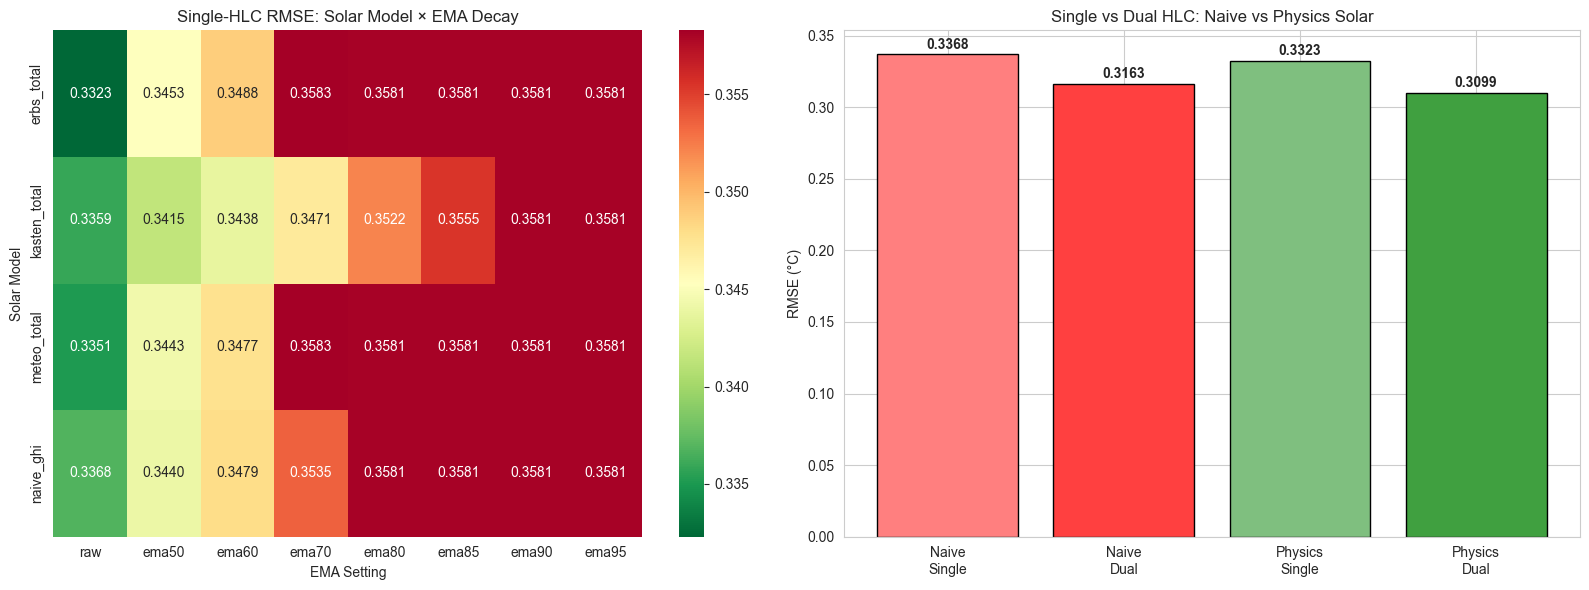

In [18]:
# --- Visualization: RMSE heatmap + bar comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: model vs EMA decay
pivot_data = []
for _, row in results_df.iterrows():
    name = row["model"]
    for base in SOLAR_MODELS:
        if name.startswith(base):
            suffix = name[len(base)+1:] if len(name) > len(base) else "raw"
            pivot_data.append({"base": base, "ema": suffix, "RMSE": row["RMSE"]})
            break

pivot_df = pd.DataFrame(pivot_data)
if len(pivot_df) > 0:
    heatmap = pivot_df.pivot(index="base", columns="ema", values="RMSE")
    col_order = ["raw"] + [f"ema{int(d*100)}" for d in DECAY_VALUES]
    heatmap = heatmap.reindex(columns=[c for c in col_order if c in heatmap.columns])
    sns.heatmap(heatmap, annot=True, fmt=".4f", cmap="RdYlGn_r", ax=axes[0])
    axes[0].set_title("Single-HLC RMSE: Solar Model × EMA Decay")
    axes[0].set_ylabel("Solar Model"); axes[0].set_xlabel("EMA Setting")

# Bar chart: 4 key configurations
configs = {
    "Naive\nSingle": single_naive_rmse,
    "Naive\nDual": dual_naive_rmse,
    f"Physics\nSingle": best_row["RMSE"],
    f"Physics\nDual": dual_physics_rmse,
}
colors = ["#ff7f7f", "#ff4040", "#7fbf7f", "#40a040"]
bars = axes[1].bar(configs.keys(), configs.values(), color=colors, edgecolor="black")
axes[1].set_ylabel("RMSE (°C)")
axes[1].set_title("Single vs Dual HLC: Naive vs Physics Solar")
for bar, val in zip(bars, configs.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout(); plt.show()

In [19]:
# --- Physical consistency checks ---
print("="*60)
print("PHYSICAL CONSISTENCY CHECK")
print("="*60)

best = results_df.loc[results_df["RMSE"].idxmin()]
print(f"\nBest physics model: {best['model']}")
print(f"  HLC      = {best['HLC']:.4f}  (expect 0.01–0.5)")
print(f"  OE       = {best['OE']:.4f}  (expect 0.1–1.0)")
print(f"  tau_h    = {best['tau_h']:.1f}h  (expect 30–100h)")
print(f"  solar_w  = {best['solar_w']:.4f}")
print(f"  RMSE     = {best['RMSE']:.4f}°C")

print(f"\n{'Model':<35s} {'HLC':>6s} {'OE':>6s} {'tau':>6s} {'sw':>8s} {'RMSE':>8s}")
print("-"*75)
for _, row in results_df.nsmallest(10, "RMSE").iterrows():
    print(f"{row['model']:<35s} {row['HLC']:>6.3f} {row['OE']:>6.3f} {row['tau_h']:>6.1f} {row['solar_w']:>8.5f} {row['RMSE']:>8.4f}")

# Physical sanity flags
print("\n--- Sanity Flags ---")
flags = []
if best["HLC"] < 0.01:
    flags.append("Warning: HLC suspiciously low — possible solar overcompensation")
elif best["HLC"] > 1.0:
    flags.append("Warning: HLC suspiciously high")
if best["tau_h"] < 10:
    flags.append("Warning: tau too low — unrealistic for concrete slab")
elif best["tau_h"] >= 99:
    flags.append("Warning: tau hit upper bound — try wider range")
if best["OE"] < 0.05:
    flags.append("Warning: OE too low — outlet barely affects indoor temp")
if not flags:
    flags.append("All parameters within expected physical ranges")
for f in flags:
    print(f"  {f}")

# Dual-HLC physical consistency
print(f"\n--- Dual-HLC Physical Analysis ---")
print(f"  HLC_on  = {hlc_on_p:.4f} (when HP active)")
print(f"  HLC_off = {hlc_off_p:.4f} (when HP off)")
print(f"  Ratio   = {hlc_on_p/max(hlc_off_p,0.001):.2f}x")
print(f"  Interpretation: HP circulation increases effective building coupling by {(hlc_on_p/max(hlc_off_p,0.001)-1)*100:.0f}%")

PHYSICAL CONSISTENCY CHECK

Best physics model: erbs_total_raw
  HLC      = 0.4391  (expect 0.01–0.5)
  OE       = 0.4863  (expect 0.1–1.0)
  tau_h    = 83.8h  (expect 30–100h)
  solar_w  = 0.4996
  RMSE     = 0.3323°C

Model                                  HLC     OE    tau       sw     RMSE
---------------------------------------------------------------------------
erbs_total_raw                       0.439  0.486   83.8  0.49957   0.3323
meteo_total_raw                      0.442  0.502   89.9  0.02694   0.3351
kasten_total_raw                     0.451  0.493   94.4  0.01668   0.3359
naive_ghi_raw                        0.430  0.488   93.5  0.02601   0.3368
kasten_total_ema50                   0.454  0.517  100.0  0.01045   0.3415
kasten_total_ema60                   0.464  0.538  100.0  0.01011   0.3438
naive_ghi_ema50                      0.452  0.526   96.1  0.01989   0.3440
meteo_total_ema50                    0.470  0.550   97.8  0.01380   0.3443
erbs_total_ema50             

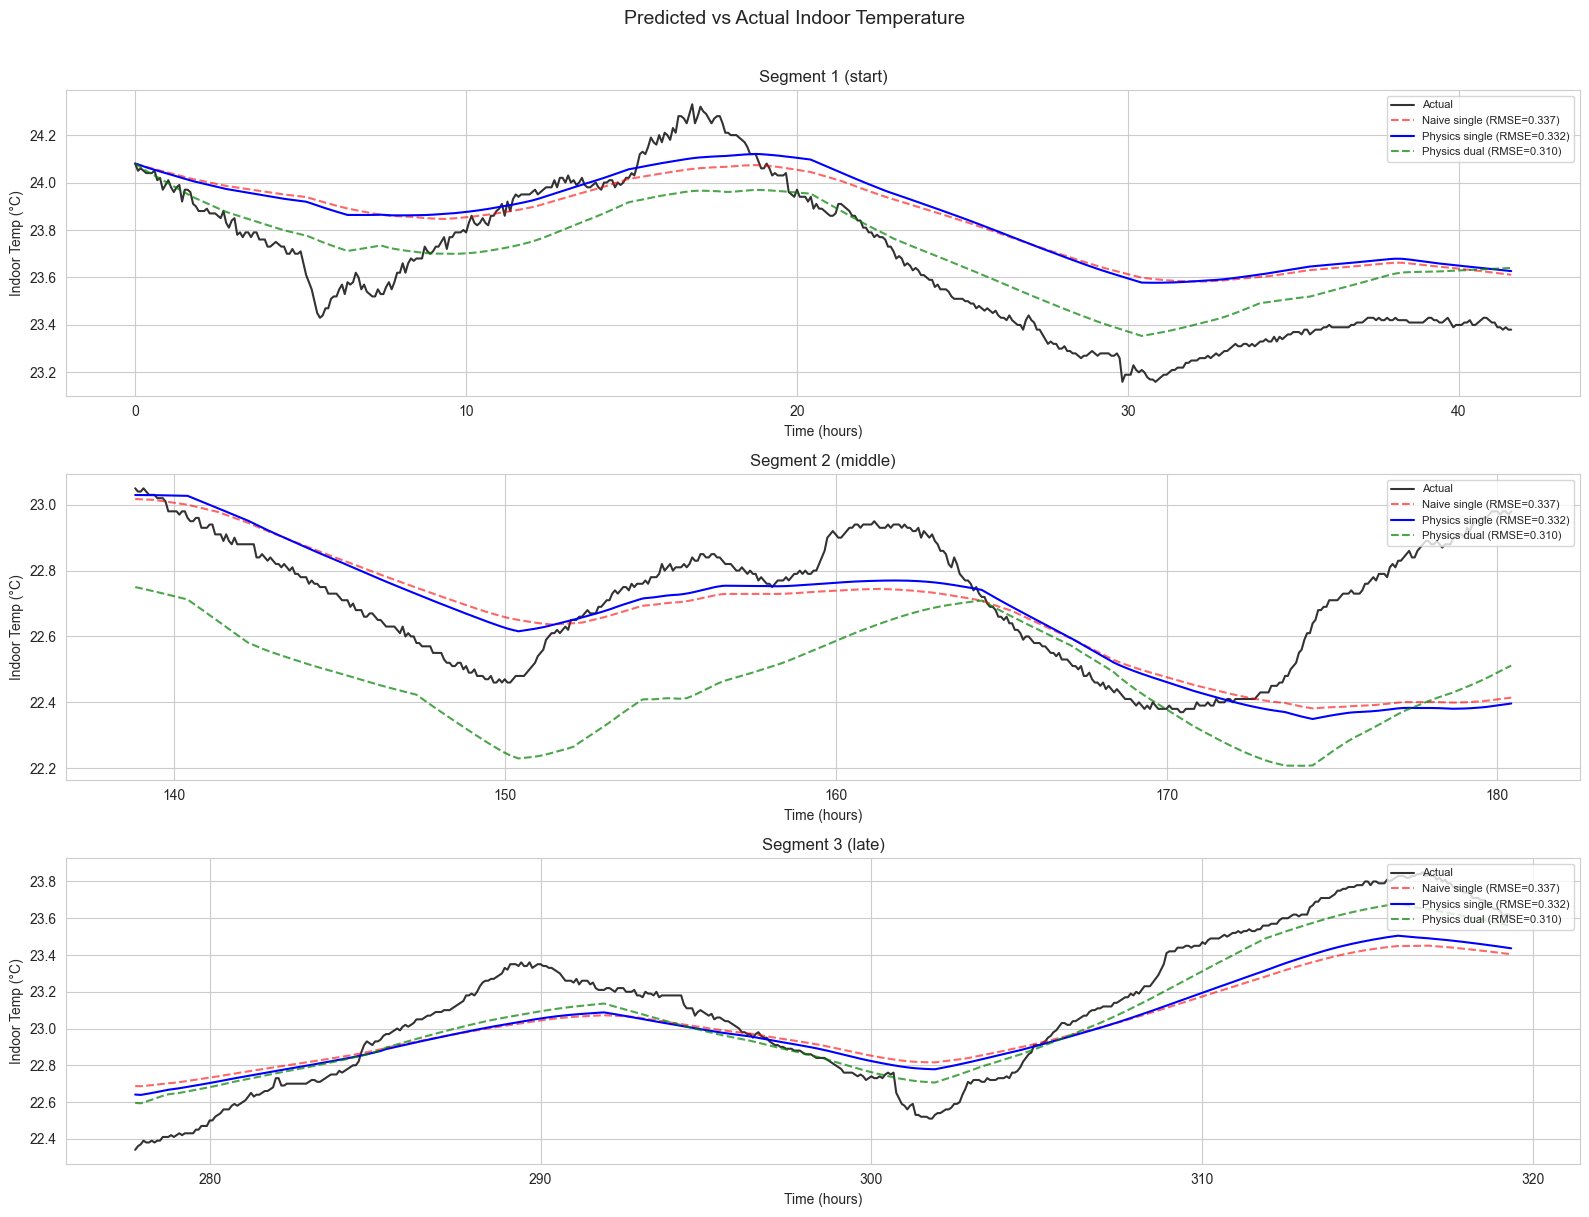

In [20]:
# --- Time-series validation: predicted vs actual ---
best_col_name = [col for name, col in combos if name == best_model][0]
arrays_val = _precompute_arrays(df_cal, best_col_name)

# Best single-HLC physics prediction
pred_single = _simulate_single_hlc(arrays_val, best["HLC"], best["OE"], best["tau_h"], best["solar_w"])
# Best dual-HLC physics prediction
pred_dual = _simulate_dual_hlc(arrays_val, hlc_on_p, hlc_off_p, oe_p, tau_p, sw_p)
# Naive single-HLC prediction
arrays_naive_val = _precompute_arrays(df_cal, "naive_ghi")
pred_naive = _simulate_single_hlc(arrays_naive_val, *res_single_naive.x)

actual = arrays_val["indoor"]

# Plot 3 representative segments (~500 points each ≈ ~1.7 days at 5-min)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
n_pts = min(500, len(actual) // 4)
segments = [
    (0, n_pts, "Segment 1 (start)"),
    (len(actual)//3, len(actual)//3 + n_pts, "Segment 2 (middle)"),
    (len(actual)*2//3, len(actual)*2//3 + n_pts, "Segment 3 (late)"),
]

for ax, (s, e, title) in zip(axes, segments):
    e = min(e, len(actual))
    x = np.arange(s, e) * DT_H  # convert to hours
    ax.plot(x, actual[s:e], "k-", label="Actual", lw=1.5, alpha=0.8)
    ax.plot(x, pred_naive[s:e], "r--", label=f"Naive single (RMSE={single_naive_rmse:.3f})", alpha=0.6)
    ax.plot(x, pred_single[s:e], "b-", label=f"Physics single (RMSE={best['RMSE']:.3f})", lw=1.5)
    ax.plot(x, pred_dual[s:e], "g--", label=f"Physics dual (RMSE={dual_physics_rmse:.3f})", alpha=0.7)
    ax.set_title(title); ax.set_ylabel("Indoor Temp (°C)")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("Time (hours)")

plt.suptitle("Predicted vs Actual Indoor Temperature", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

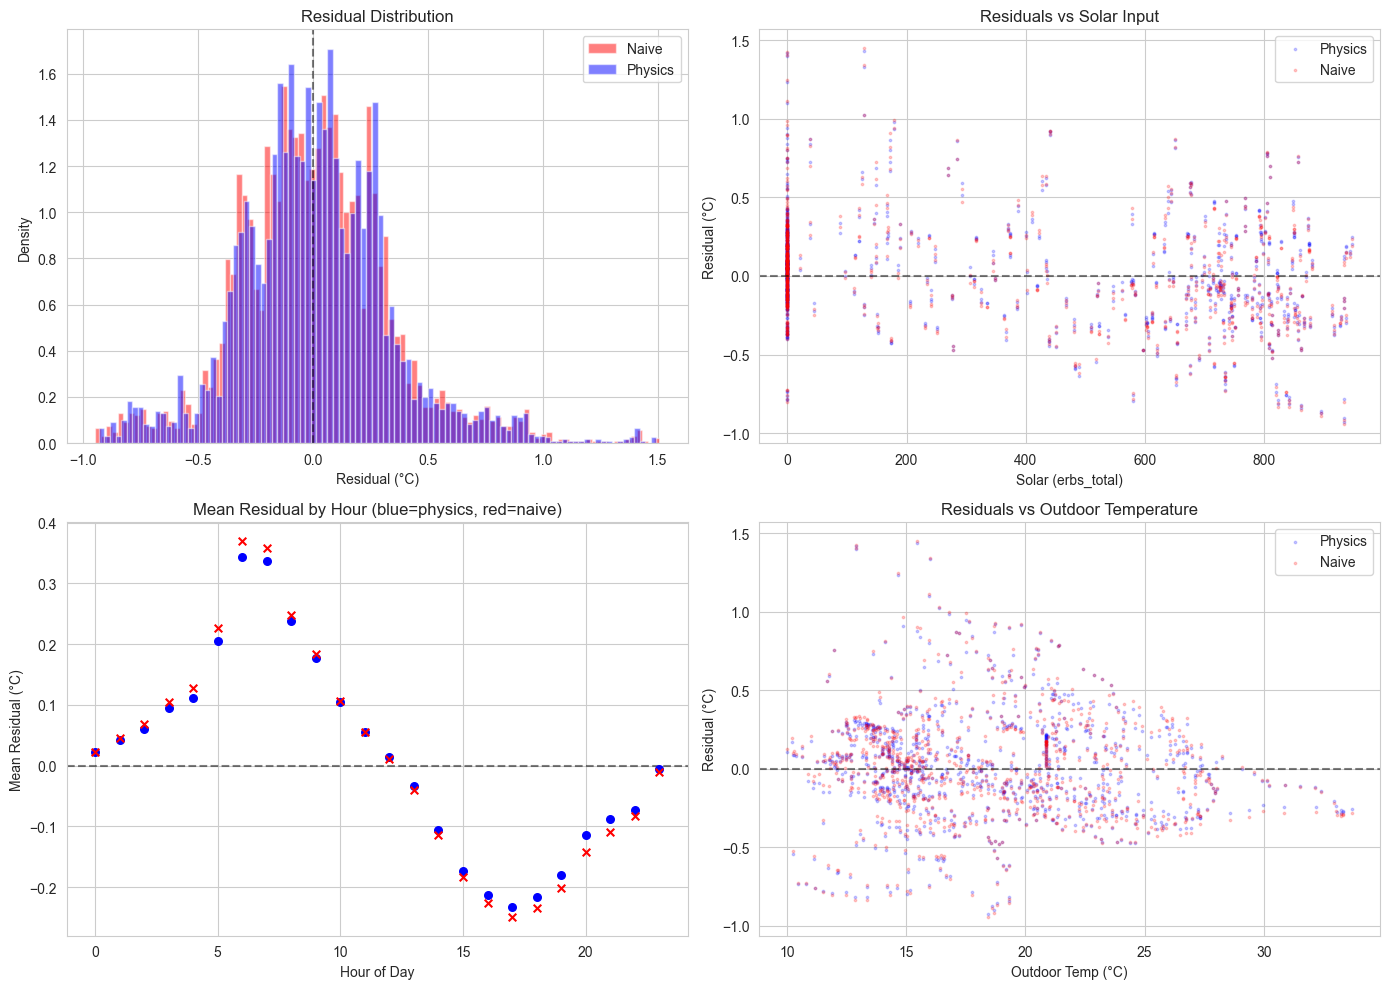


MAE (Naive):   0.2539°C
MAE (Physics): 0.2491°C
Max error (Physics): 1.50°C
95th pctl error: 0.740°C


In [21]:
# --- Residual analysis ---
residuals_physics = pred_single - actual
residuals_naive = pred_naive - actual

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual distribution
ax = axes[0, 0]
ax.hist(residuals_naive, bins=100, alpha=0.5, label="Naive", color="red", density=True)
ax.hist(residuals_physics, bins=100, alpha=0.5, label="Physics", color="blue", density=True)
ax.set_xlabel("Residual (°C)"); ax.set_ylabel("Density")
ax.set_title("Residual Distribution"); ax.legend()
ax.axvline(0, color="black", ls="--", alpha=0.5)

# Residuals vs solar
ax = axes[0, 1]
solar_vals = df_cal[best_col_name].values
ax.scatter(solar_vals[::5], residuals_physics[::5], alpha=0.2, s=3, c="blue", label="Physics")
ax.scatter(solar_vals[::5], residuals_naive[::5], alpha=0.2, s=3, c="red", label="Naive")
ax.set_xlabel(f"Solar ({best_col_name})"); ax.set_ylabel("Residual (°C)")
ax.set_title("Residuals vs Solar Input"); ax.legend()
ax.axhline(0, color="black", ls="--", alpha=0.5)

# Residuals vs hour of day
ax = axes[1, 0]
hour_vals = df_cal["hour_approx"].values
for h in range(24):
    mask = hour_vals == h
    if mask.sum() > 0:
        ax.scatter(h, np.mean(residuals_physics[mask]), c="blue", s=30, zorder=5)
        ax.scatter(h, np.mean(residuals_naive[mask]), c="red", s=30, marker="x", zorder=5)
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Mean Residual (°C)")
ax.set_title("Mean Residual by Hour (blue=physics, red=naive)")
ax.axhline(0, color="black", ls="--", alpha=0.5)

# Residuals vs outdoor temp
ax = axes[1, 1]
at_vals = df_cal["AT"].values
ax.scatter(at_vals[::5], residuals_physics[::5], alpha=0.2, s=3, c="blue", label="Physics")
ax.scatter(at_vals[::5], residuals_naive[::5], alpha=0.2, s=3, c="red", label="Naive")
ax.set_xlabel("Outdoor Temp (°C)"); ax.set_ylabel("Residual (°C)")
ax.set_title("Residuals vs Outdoor Temperature"); ax.legend()
ax.axhline(0, color="black", ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

print(f"\nMAE (Naive):   {np.mean(np.abs(residuals_naive)):.4f}°C")
print(f"MAE (Physics): {np.mean(np.abs(residuals_physics)):.4f}°C")
print(f"Max error (Physics): {np.max(np.abs(residuals_physics)):.2f}°C")
print(f"95th pctl error: {np.percentile(np.abs(residuals_physics), 95):.3f}°C")

In [22]:
# --- Final Summary ---
print("="*80)
print("NB13 — PHYSICS SOLAR CALIBRATION SUMMARY")
print("="*80)

print(f"\n1. RMSE COMPARISON (on {N_CAL} rows, dt={DT_H*60:.0f}min)")
print(f"   Naive GHI + Single-HLC:    {single_naive_rmse:.4f}°C  (HLC={res_single_naive.x[0]:.3f}, tau={res_single_naive.x[2]:.1f}h)")
print(f"   Naive GHI + Dual-HLC:      {dual_naive_rmse:.4f}°C  (HLC_on={hlc_on_n:.3f}, HLC_off={hlc_off_n:.3f})")
print(f"   Physics + Single-HLC:      {best_row['RMSE']:.4f}°C  (HLC={best['HLC']:.3f}, tau={best['tau_h']:.1f}h)")
print(f"   Physics + Dual-HLC:        {dual_physics_rmse:.4f}°C  (HLC_on={hlc_on_p:.3f}, HLC_off={hlc_off_p:.3f})")

improvement = single_naive_rmse - best_row["RMSE"]
print(f"\n2. PHYSICS SOLAR IMPROVEMENT: {improvement:.4f}°C ({100*improvement/single_naive_rmse:.1f}%)")
print(f"   Best model: {best_model} (Erbs GHI→DNI/DHI decomposition, raw)")

print(f"\n3. DUAL-HLC GAP ANALYSIS")
print(f"   With naive solar:   single→dual gap = {naive_gap:.4f}°C")
print(f"   With physics solar: single→dual gap = {physics_gap:.4f}°C")
if naive_gap > 0.001:
    gap_change = (physics_gap - naive_gap) / naive_gap * 100
    print(f"   Gap change: {gap_change:+.1f}%")

print(f"\n4. KEY PHYSICAL PARAMETERS")
print(f"   HLC (single):  {best['HLC']:.3f} (building envelope conductance)")
print(f"   HLC_on/off:    {hlc_on_p:.3f} / {hlc_off_p:.3f} (ratio {hlc_on_p/max(hlc_off_p,0.001):.1f}x)")
print(f"   OE:            {best['OE']:.3f} (outlet effectiveness)")
print(f"   tau:            {best['tau_h']:.0f}h (thermal time constant)")
print(f"   solar_w:        {best['solar_w']:.4f}")

print(f"\n5. SOLAR MODEL RANKING (single-HLC, raw only)")
for _, row in results_df[results_df["model"].str.endswith("_raw")].nsmallest(5, "RMSE").iterrows():
    print(f"   {row['model']:<25s} RMSE={row['RMSE']:.4f}°C")

print(f"\n6. EMA THERMAL BATTERY: NOT beneficial — raw signal always best")
print(f"   (Heavy thermal mass already integrates solar; EMA over-smooths)")

print(f"\n7. CONCLUSION:")
print(f"   ❌ Physics solar does NOT close the dual-HLC gap.")
print(f"   → The dual-HLC effect (HLC_on ≈ 2.5× HLC_off) is REAL,")
print(f"     not an artifact of missing solar physics.")
print(f"   → Possible cause: HP circulation creates convective mixing")
print(f"     that increases effective building-outdoor coupling.")
print(f"   → Physics solar gives a small improvement ({improvement:.4f}°C, {100*improvement/single_naive_rmse:.1f}%)")
print(f"     but the Erbs directional model is only marginally better than naive GHI.")

NB13 — PHYSICS SOLAR CALIBRATION SUMMARY

1. RMSE COMPARISON (on 5000 rows, dt=5min)
   Naive GHI + Single-HLC:    0.3368°C  (HLC=0.430, tau=93.5h)
   Naive GHI + Dual-HLC:      0.3163°C  (HLC_on=0.705, HLC_off=0.262)
   Physics + Single-HLC:      0.3323°C  (HLC=0.439, tau=83.8h)
   Physics + Dual-HLC:        0.3099°C  (HLC_on=0.690, HLC_off=0.275)

2. PHYSICS SOLAR IMPROVEMENT: 0.0045°C (1.3%)
   Best model: erbs_total_raw (Erbs GHI→DNI/DHI decomposition, raw)

3. DUAL-HLC GAP ANALYSIS
   With naive solar:   single→dual gap = 0.0205°C
   With physics solar: single→dual gap = 0.0224°C
   Gap change: +9.5%

4. KEY PHYSICAL PARAMETERS
   HLC (single):  0.439 (building envelope conductance)
   HLC_on/off:    0.690 / 0.275 (ratio 2.5x)
   OE:            0.486 (outlet effectiveness)
   tau:            84h (thermal time constant)
   solar_w:        0.4996

5. SOLAR MODEL RANKING (single-HLC, raw only)
   erbs_total_raw            RMSE=0.3323°C
   meteo_total_raw           RMSE=0.3351°C
   ka